In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2)

from imagen_pytorch import ElucidatedImagen, ImagenTrainer, Unet3D

import conf.dataset
from conf import conf
from g_led import main_upsampler, datasets, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [51]:
runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        # ['94t1h2nk', 'model'],
        # ['salhr30y', 'model'],
        # ['729ljxk5', 'epoch_count=20'],  # epoch = 20
        # ['w3jrt6ub', 'epoch_count=200'],  # epoch = 200
        # ['xlues2v0', 'epoch_count=1000'],  # epoch = 1000
        ['s4a38hbi', 'epoch_count=1800'],  # epoch = 1800
    ]
)
runs

alt_id,label
str,str
"""s4a38hbi""","""epoch_count=1800"""


In [52]:
splits = [
    'train',
    # 'val_on_train',
    # 'val',
    # 'test',
]
cfgs = db.execute(conf.sa.select(conf.Conf).where(conf.Conf.alt_id.in_(runs.get_column('alt_id'))))
cfgs = {cfg.alt_id: {'cfg': cfg} for (cfg,) in cfgs}
reference_cfg = next(iter(cfgs.values()))['cfg']
for alt_id in runs.get_column('alt_id'):
    cfg = cfgs[alt_id]['cfg']
    assert cfg.dataset.id == reference_cfg.dataset.id
    cfgs[alt_id]['splits'] = {}
    for split in splits:
        cfgs[alt_id]['splits'][split] = torch.load(cfg.run_dir/f'pred_{split}.pt')
downsampler = datasets.Downsampler(reference_cfg.dataset)
upsampler = datasets.Upsampler(reference_cfg.dataset)
lightning.pytorch.seed_everything(reference_cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dataset = datasets.get_dataset(reference_cfg.dataset)
    dataset.prepare_data()
    dataset.setup('predict')
cfgs['True'] = {'cfg': None, 'splits': {}}
cfgs['LinearInterpolation'] = {'cfg': None, 'splits': {}}
for split in splits:
    dataset_split = getattr(dataset, split)
    cfgs['True']['splits'][split] = dataset_split
    dataset_split = dataset_split.reshape(-1).reshape(dataset_split.shape)
    cfgs['LinearInterpolation']['splits'][split] = upsampler(downsampler(dataset_split))

Seed set to 2376999025


In [53]:
for split, prediction in cfgs['LinearInterpolation']['splits'].items():
    print(f'{split}: {prediction.shape}')

train: torch.Size([11, 10, 2, 512, 512])


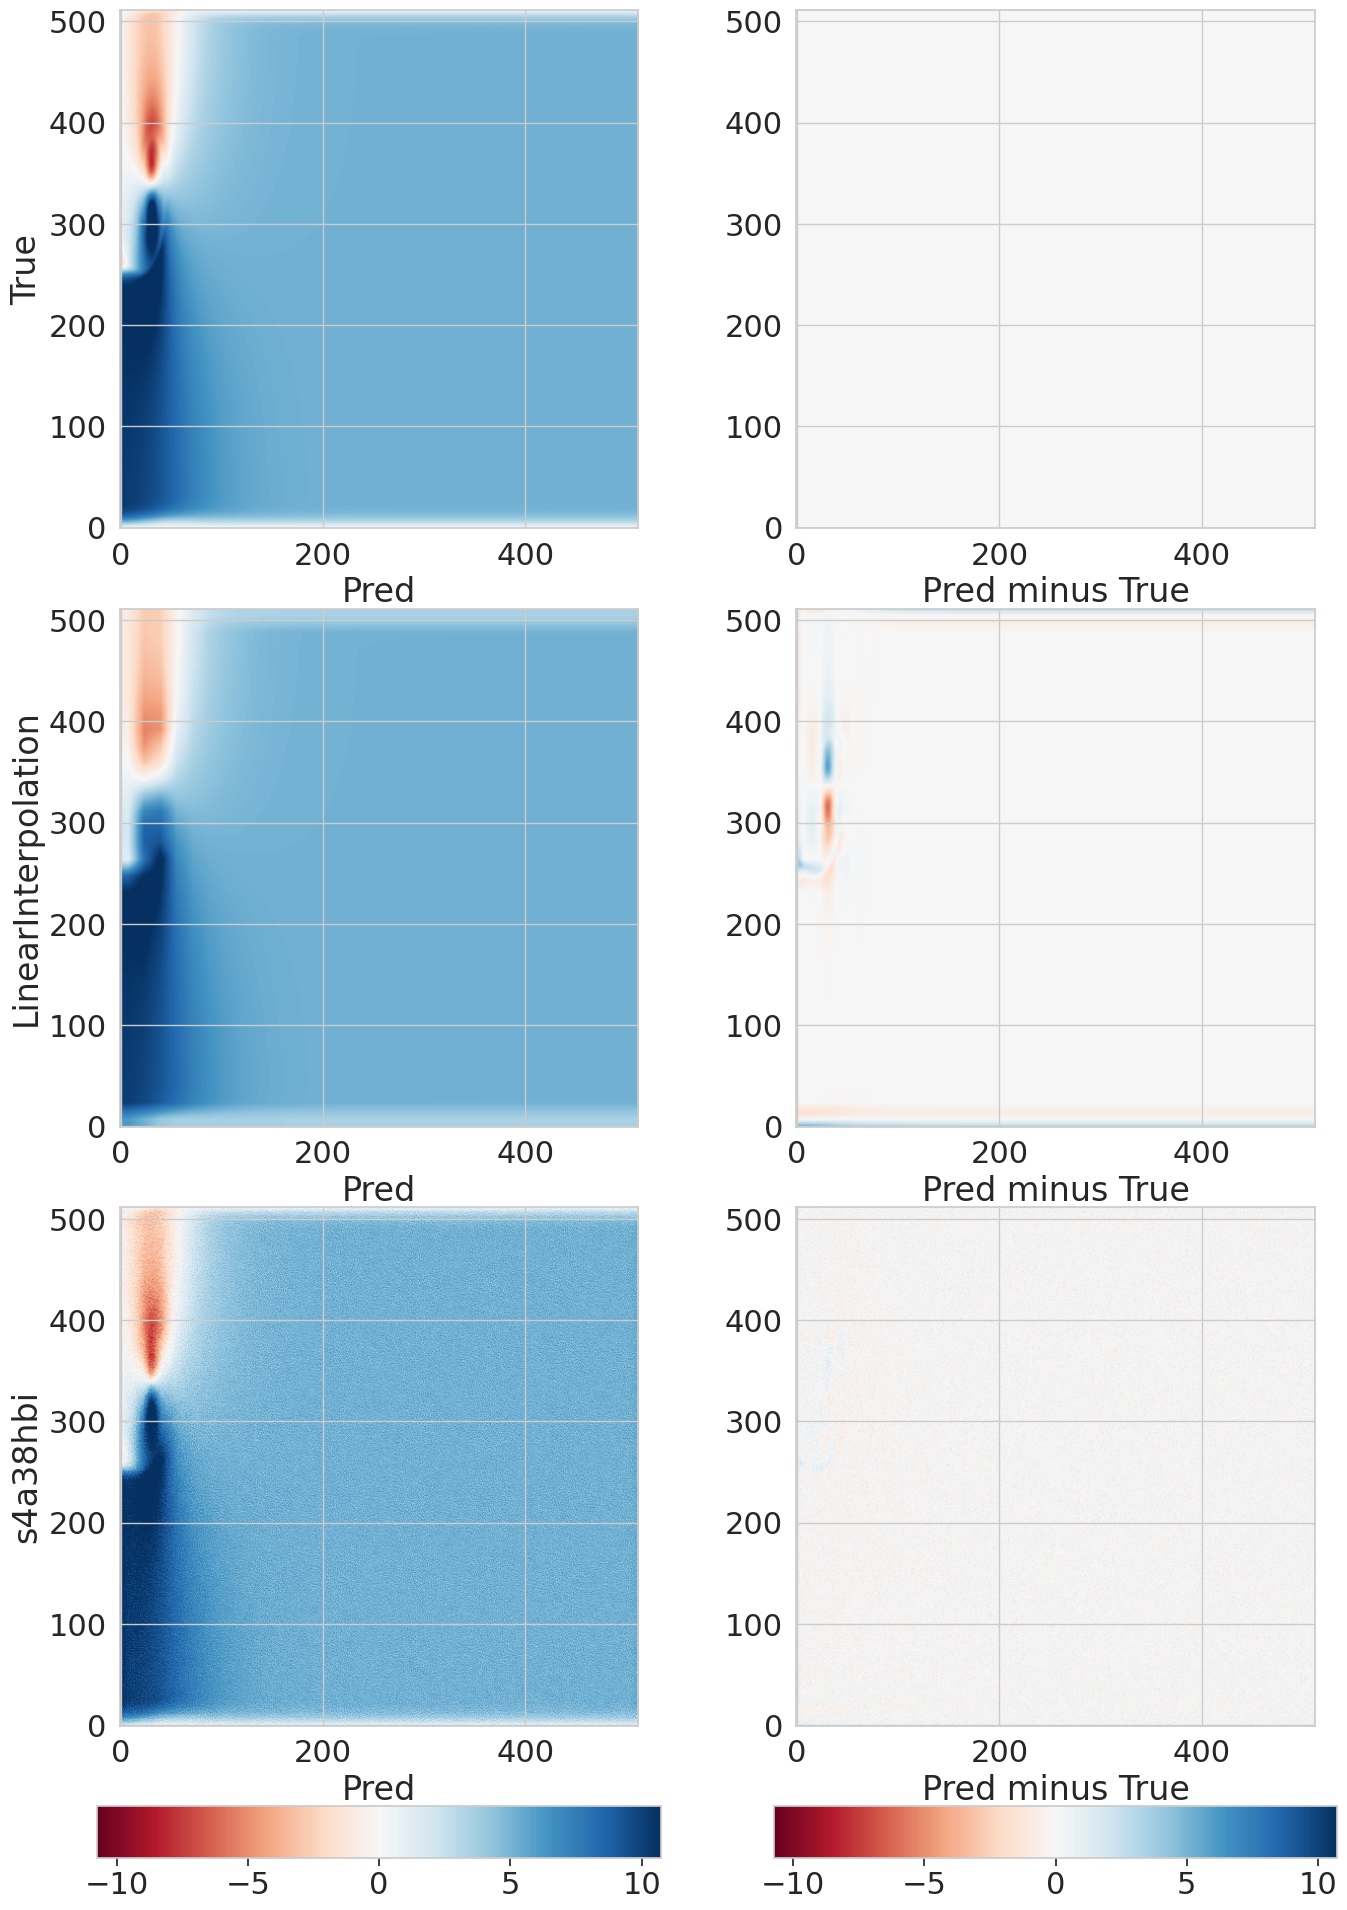

In [54]:
split = 'train'
batch = 0
time_step = 0
component = 0
row_order = ['True', 'LinearInterpolation', *runs.get_column('alt_id')]

data_true = cfgs['True']['splits'][split][batch, time_step, component].numpy()
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))

fig, axs = plt.subplots(figsize=(16, 6 + 6 * len(cfgs)), nrows=len(cfgs) + 1, ncols=2, height_ratios=[*([10] * len(cfgs)), 1])
for axs_row, (model_id, context) in zip(axs, {k: cfgs[k] for k in row_order}.items()):
    data = context['splits'][split][batch, time_step, component].numpy()
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(model_id)
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')

In [55]:
reference_runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['True', 'True'],  # epoch = 20
        ['LinearInterpolation', 'Linear Interpolation'],
    ]
)

shape: (30, 4)
┌──────────────────┬─────────────────────┬───────────────────────┬──────────────────────┐
│ window_time_step ┆ alt_id              ┆ Mean(Batch) Rel. RMSE ┆ label                │
│ ---              ┆ ---                 ┆ ---                   ┆ ---                  │
│ i64              ┆ str                 ┆ f32                   ┆ str                  │
╞══════════════════╪═════════════════════╪═══════════════════════╪══════════════════════╡
│ 0                ┆ s4a38hbi            ┆ 0.453214              ┆ epoch_count=1800     │
│ 1                ┆ s4a38hbi            ┆ 0.439644              ┆ epoch_count=1800     │
│ 2                ┆ s4a38hbi            ┆ 0.434651              ┆ epoch_count=1800     │
│ 3                ┆ s4a38hbi            ┆ 0.428803              ┆ epoch_count=1800     │
│ 4                ┆ s4a38hbi            ┆ 0.423223              ┆ epoch_count=1800     │
│ …                ┆ …                   ┆ …                     ┆ …                 

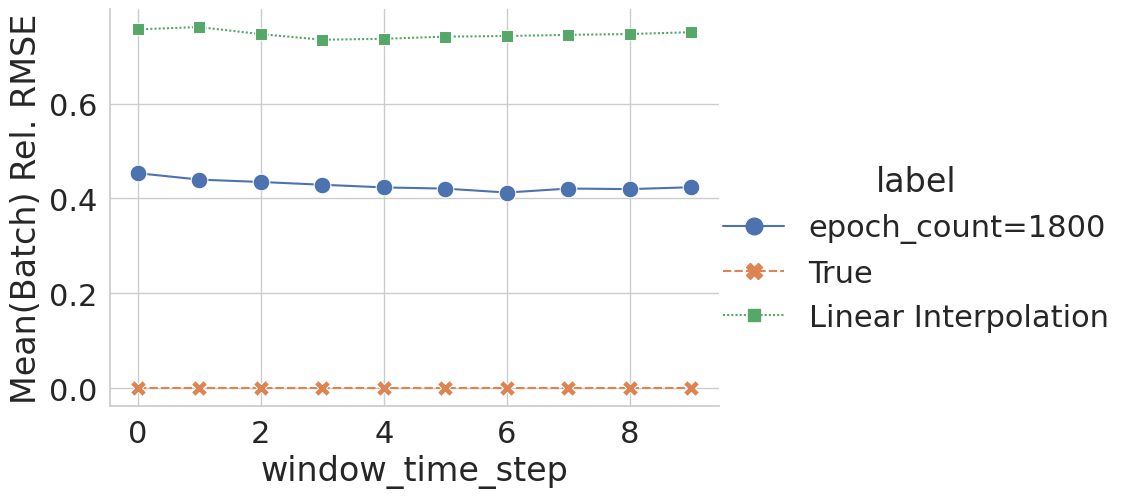

In [56]:
split = 'train'
data_true = cfgs['True']['splits'][split]
rel_rmses = {}
for model_id, context in cfgs.items():
    data = context['splits'][split]
    rmse = reduce(
        (data - data_true).abs(),
        'batch time component width length -> batch time',
        'max'
    ).sqrt()
    norm = reduce(
        data_true.abs(),
        'batch time component width length -> batch time',
        'max'
    ).sqrt()
    rel_rmses[model_id] = (rmse / norm).mean(0).numpy()
    # rmse = reduce(
    #     (data - data_true)[:1, :1, :1].square(),
    #     'batch time component width length -> batch time',
    #     'mean'
    # ).sqrt()
    # norm = reduce(
    #     data_true[:1, :1, :1].square(),
    #     'batch time component width length -> batch time',
    #     'mean'
    # ).sqrt()
    # rel_rmses[model_id] = (rmse / norm).mean(0).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(pl.len()))
# print(rel_rmses)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='alt_id', value_name='Mean(Batch) Rel. RMSE')
    .join(pl.concat([runs, reference_runs]), on='alt_id', how='left')
)
print(plot_data)
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='Mean(Batch) Rel. RMSE',
        # hue_order=row_order,
        # style_order=row_order,
        hue='label',
        style='label',
        markers=True,
        markersize=12,
        height=5.5,
        aspect=1.5,
    )
)